In this notebook I first run the sections presented in https://github.com/neurogym/neurogym/blob/main/docs/examples/understanding_neurogym_task.ipynb and then I write down the PerceptualDecisionMaking-v0 and Go-NoGo task
explicitly and write an explanation of the tasks in the doc-string.

In [2]:
import numpy as np
import gymnasium as gym


class MyEnv(gym.Env):
    def __init__(self):
        super().__init__()  # Python boilerplate to initialize base class
        self.observation_space = gym.spaces.Box(low=-10.0, high=10.0, shape=(1,))
        self.action_space = gym.spaces.Discrete(3)

    def step(self, action):
        ob = self.observation_space.sample()  # random sampling
        reward = 1.0  # reward
        terminated = False  # never ending
        truncated = False
        info = {}  # empty dictionary
        return ob, reward, terminated, truncated, info

    def reset(self):
        ob = self.observation_space.sample()
        return ob, {}

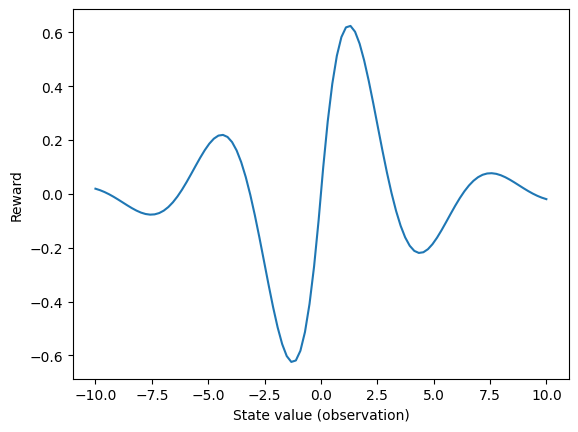

In [3]:
import matplotlib.pyplot as plt

def get_reward(x):
    return np.sin(x) * np.exp(-np.abs(x) / 3)

xs = np.linspace(-10, 10, 100)
plt.plot(xs, get_reward(xs))
plt.xlabel("State value (observation)")
plt.ylabel("Reward");

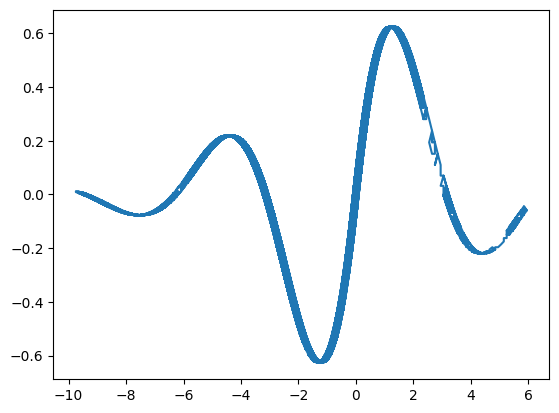

In [4]:
class MyEnv(gym.Env):
    def __init__(self):
        # A one-dimensional box with minimum and maximum value set by low and high
        self.observation_space = gym.spaces.Box(low=-10.0, high=10.0, shape=(1,))

        # A discrete space with 3 possible values (0, 1, 2)
        self.action_space = gym.spaces.Discrete(3)

        self.state = 0.0

    def step(self, action):
        # Actions 0, 1, 2 correspond to state change of -0.1, 0, +0.1
        self.state += (action - 1.0) * 0.1
        self.state = np.clip(self.state, -10, 10)

        ob = self.state  # observation
        reward = get_reward(self.state)  # reward
        terminated = False  # never ending
        truncated = False
        info = {}  # empty dictionary
        return ob, reward, terminated, truncated, info

    def reset(self):
        # Re-initialize state
        self.state = self.observation_space.sample()
        return self.state, {}

env = MyEnv()
ob, _ = env.reset()
ob_log = list()
reward_log = list()
for i in range(10000):
    action = env.action_space.sample()  # A random agent
    ob, reward, terminated, truncated, info = env.step(action)
    ob_log.append(ob)
    reward_log.append(reward)

plt.plot(ob_log, reward_log);

In [5]:
import neurogym as ngym
from neurogym.core import TrialEnv
from IPython.display import clear_output
clear_output()

class MyTrialEnv(TrialEnv):
    def __init__(self):
        super().__init__()
        self.observation_space = gym.spaces.Box(low=-1.0, high=1.0, shape=(1,))
        self.action_space = gym.spaces.Discrete(2)

        self.next_ob = np.random.uniform(-1, 1, size=(1,))

    def _post_init(self):
        """Perform sanity checks."""
        super()._post_init(allow_empty_timing=True)

    def _new_trial(self):
        ob = self.next_ob  # observation previously computed
        # Sample observation for the next trial
        self.next_ob = np.random.uniform(-1, 1, size=(1,))

        trial = dict()
        # Ground-truth is 1 if ob > 0, else 0
        trial["ground_truth"] = (ob > 0) * 1.0

        return trial

    def _step(self, action):
        ob = self.next_ob
        # If action equals to ground_truth, reward=1, otherwise 0
        reward = (action == self.trial["ground_truth"]) * 1.0
        terminated = False
        truncated = False
        info = {"new_trial": True}
        return ob, reward, terminated, truncated, info
env = MyTrialEnv()
ob, _ = env.reset()

print("Trial", 0)
print("Received observation", ob)

for i in range(5):
    action = env.action_space.sample()  # A random agent
    print("Selected action", action)
    ob, reward, terminated, truncated, info = env.step(action)
    print("Received reward", reward)
    print("Trial", i + 1)
    print("Received observation", ob)

Trial 0
Received observation [-0.48022742]
Selected action 1
Received reward [0.]
Trial 1
Received observation [-0.30820181]
Selected action 1
Received reward [0.]
Trial 2
Received observation [-0.17716726]
Selected action 0
Received reward [1.]
Trial 3
Received observation [-0.82825801]
Selected action 0
Received reward [1.]
Trial 4
Received observation [-0.8721637]
Selected action 0
Received reward [1.]
Trial 5
Received observation [0.48868326]


In [6]:
class MyDecisionEnv(TrialEnv):
    def __init__(self, dt=100, timing=None):
        super().__init__(dt=dt)  # dt is passed to base task

        # Setting default task timing
        self.timing = {"stimulus": 500, "decision": 500}
        # Update timing if provided externally
        if timing:
            self.timing.update(timing)

        self.observation_space = gym.spaces.Box(low=-1.0, high=1.0, shape=(1,))
        self.action_space = gym.spaces.Discrete(2)

    def _new_trial(self):
        # Setting time periods for this trial
        periods = ["stimulus", "decision"]
        # Will add stimulus and decision periods sequentially using self.timing info
        # Internally, TrialEnv:
        # Iterates through the list in order
        # Looks up each name in self.timing
        # Converts duration (ms) → number of time steps using dt
        # Assigns start and end indices on a trial timeline
        self.add_period(periods)

        # Sample observation for the next trial
        stimulus = np.random.uniform(-1, 1, size=(1,))

        trial = dict()
        trial["stimulus"] = stimulus
        # Ground-truth is 1 if stimulus > 0, else 0
        trial["ground_truth"] = (stimulus > 0) * 1.0

        return trial

    def _step(self, action):
        # Check if the current time step is in stimulus period
        if self.in_period("stimulus"):
            ob = np.array([self.trial["stimulus"]])
            reward = 0.0  # no reward
        else:
            ob = np.array([0.0])  # no observation
            # If action equals to ground_truth, reward=1, otherwise 0
            reward = (action == self.trial["ground_truth"]) * 1.0

        terminated = False
        truncated = False
        # By default, the trial is not ended
        info = {"new_trial": False}
        return ob, reward, terminated, truncated, info

/tmp/ipykernel_490338/2643671980.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  log["ob"].append(float(ob))
/tmp/ipykernel_490338/2643671980.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  log["gt"].append(float(ob > 0))
/tmp/ipykernel_490338/2643671980.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  log["ob"].append(float(ob))
/tmp/ipykernel_490338/2643671980.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, a

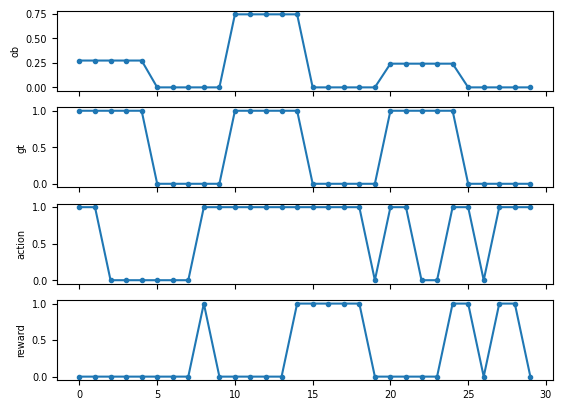

In [7]:
# Logging
log = {"ob": [], "gt": [], "action": [], "reward": []}

env = MyDecisionEnv(dt=100)
ob, _ = env.reset()
log["ob"].append(float(ob))
log["gt"].append(float(ob > 0))
for i in range(30):
    action = env.action_space.sample()  # A random agent
    ob, reward, terminated, truncated, info = env.step(action)

    log["action"].append(float(action))
    log["ob"].append(float(ob))
    log["gt"].append(float(ob > 0))
    log["reward"].append(float(reward))

log["ob"] = log["ob"][:-1]  # exclude last observation
log["gt"] = log["gt"][:-1]  # exclude last observation
# Visualize
f, axes = plt.subplots(len(log), 1, sharex=True)
for ax, key in zip(axes, log):
    ax.plot(log[key], ".-")
    ax.set_ylabel(key)

In [8]:
class MyDecisionEnv(TrialEnv):
    def __init__(self, dt=100, timing=None):
        super().__init__(dt=dt)  # dt is passed to base task

        # Setting default task timing
        self.timing = {"stimulus": 500, "decision": 500}
        # Update timing if provided externally
        if timing:
            self.timing.update(timing)

        # Here we use ngym.spaces, which allows setting name of each dimension
        name = {"fixation": 0, "stimulus": 1}
        self.observation_space = ngym.spaces.Box(
            low=-1.0, high=1.0, shape=(2,), name=name
        )
        name = {"fixation": 0, "choice": [1, 2]}
        self.action_space = ngym.spaces.Discrete(3, name=name)

    def _new_trial(self):
        # Setting time periods for this trial
        periods = ["stimulus", "decision"]
        # Will add stimulus and decision periods sequentially using self.timing info
        self.add_period(periods)

        # Sample observation for the next trial
        stimulus = np.random.uniform(-1, 1, size=(1,))

        # Add value 1 to stimulus period at fixation location
        self.add_ob(1, period="stimulus", where="fixation")
        # Add value stimulus to stimulus period at stimulus location
        self.add_ob(stimulus, period="stimulus", where="stimulus")

        # Set ground_truth
        groundtruth = int(stimulus[0] > 0)
        self.set_groundtruth(groundtruth, period="decision", where="choice")

        trial = dict()
        trial["stimulus"] = stimulus
        trial["ground_truth"] = groundtruth

        return trial

    def _step(self, action):
        # self.ob_now and self.gt_now correspond to
        # current step observation and groundtruth

        # If action equals to ground_truth, reward=1, otherwise 0
        reward = (action == self.gt_now) * 1.0

        terminated = False
        truncated = False
        # By default, the trial is not ended
        info = {"new_trial": False}
        return self.ob_now, reward, terminated, truncated, info
env = MyDecisionEnv()
env.reset()

trial = env.new_trial()
ob, gt = env.ob, env.gt

print("Trial information", trial)
print("Observation shape is (N_time, N_unit) =", ob.shape)
print("Groundtruth shape is (N_time,) =", gt.shape)

Trial information {'stimulus': array([-0.89656567]), 'ground_truth': 0}
Observation shape is (N_time, N_unit) = (10, 2)
Groundtruth shape is (N_time,) = (10,)


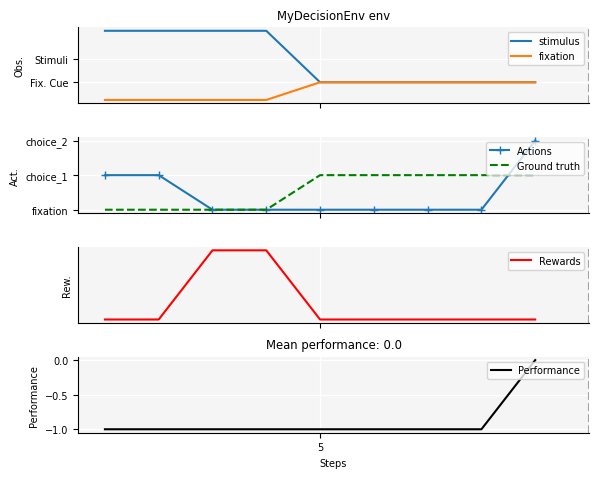

In [9]:
# Run the environment for 2 trials using a random agent.
fig = ngym.utils.plot_env(
    env,
    ob_traces=["stimulus", "fixation"],
    num_trials=1,
)

In [ ]:
class PerceptualDecisionMaking(TrialEnv):
    """Two-alternative forced choice task in which the subject has to
    integrate two stimuli to decide which one is higher on average.
    
    In this task, there is a fixation, stimulus, delay, decision period.
    The stimulus is thought of as a ring structure, so if the dim_ring is
    2, there will be 2 inputs corresponding to 0 and pi. And the choices
    would also be 2, corresponding to each input. The observation space
    is a list of 3 numbers: one for the fixation, and the next ones for
    the stimulus strength of the two inputs (if dim_ring = 2). If dt=100,
    and the fixation duration is 100, only 1 timestep will be fixation=1.
    The action space is discrete,
    so there will be just a scalar action: 0 means fixate, 1 means first 
    choice and 2 means second choice. For each trial, the ground truth
    is chosen at random, and also a level of coherence is chosen at random
    such that the trial is more or less difficult.
    For example, if the groun_truth=0, then stim_theta=0.
    During "fixation", "stimulus", "delay", the fixation value is 1.
    The stimulus of the two channels is given by
    stim = np.cos(self.theta - stim_theta) * (coh / 200) + 0.5,
    so stim = np.cos([0, pi] - 0) * (coh / 200) + 0.5,
    stim = [0.5 + coh/200, 0.5 - coh/200], so the stimulus which corresponds
    to the ground truth has a higher amplitude. Depending on how strong
    the coherence is, the difference between them is higher or lower.
    Because noise is also added to the system, having a high coh means
    the trial is easy, as stimulus 2 will always be below stimulus 1
    for example.
    if ground_truth = 0 → gt during decision is 1
    if ground_truth = 1 → gt during decision is 2
    because name = {"fixation": 0, "choice": range(1, dim_ring + 1)},
    so "choice" = [1, 2]. The ground truth just points to the index of
    the choice.
    During action space, if we are in the fixation period, the action
    has to be 0, otherwise we imply a penalty. If we are during the decision period,
    a new trial is automatically generated for the next event, and
    if the action the agent took is equal to the ground truth at that moment,
    we get a positive reward, otherwise a negative reward.    
     

    Args:
        stim_scale: Controls the difficulty of the experiment. (def: 1., float)
        sigma: float, input noise level
        dim_ring: int, dimension of ring input and output
    """

    metadata = {
        "paper_link": "https://www.jneurosci.org/content/12/12/4745",
        "paper_name": """The analysis of visual motion: a comparison of
        neuronal and psychophysical performance""",
        "tags": ["perceptual", "two-alternative", "supervised"],
    }

    def __init__(
        self, dt=100, rewards=None, timing=None, stim_scale=1.0, sigma=1.0, dim_ring=2
    ):
        super().__init__(dt=dt)
        # The strength of evidence, modulated by stim_scale
        self.cohs = np.array([0, 6.4, 12.8, 25.6, 51.2]) * stim_scale
        self.sigma = sigma / np.sqrt(self.dt)  # Input noise

        # Rewards
        self.rewards = {"abort": -0.1, "correct": +1.0, "fail": 0.0}
        if rewards:
            self.rewards.update(rewards)

        self.timing = {"fixation": 100, "stimulus": 2000, "delay": 0, "decision": 100}
        if timing:
            self.timing.update(timing)

        self.abort = False

        self.theta = np.linspace(0, 2 * np.pi, dim_ring + 1)[:-1]
        self.choices = np.arange(dim_ring)

        name = {"fixation": 0, "stimulus": range(1, dim_ring + 1)}
        self.observation_space = ngym.spaces.Box( # Box just means that the input is not just a scalar but a list like [fixation, stimulus1, stimulus2]
            -np.inf, np.inf, shape=(1 + dim_ring,), dtype=np.float32, name=name
        )
        name = {"fixation": 0, "choice": range(1, dim_ring + 1)}
        # Actions can either be 0, 1, and 2.
        self.action_space = ngym.spaces.Discrete(1 + dim_ring, name=name)

    def _new_trial(self, **kwargs):
        # Trial info
        trial = {
            "ground_truth": self.rng.choice(self.choices),
            "coh": self.rng.choice(self.cohs),
        }
        trial.update(kwargs)

        coh = trial["coh"]
        ground_truth = trial["ground_truth"]
        stim_theta = self.theta[ground_truth]

        # Periods
        self.add_period(["fixation", "stimulus", "delay", "decision"])

        # Observations
        self.add_ob(1, period=["fixation", "stimulus", "delay"], where="fixation")
        stim = np.cos(self.theta - stim_theta) * (coh / 200) + 0.5
        self.add_ob(stim, "stimulus", where="stimulus")
        self.add_randn(0, self.sigma, "stimulus", where="stimulus")

        # Ground truth
        self.set_groundtruth(ground_truth, period="decision", where="choice")

        return trial

    def _step(self, action):
        new_trial = False
        terminated = False
        truncated = False
        # rewards
        reward = 0
        gt = self.gt_now
        # observations
        if self.in_period("fixation"):
            if action != 0:  # action = 0 means fixating
                new_trial = self.abort
                reward += self.rewards["abort"]
        elif self.in_period("decision"):
            if action != 0:
                new_trial = True
                if action == gt:
                    reward += self.rewards["correct"]
                    self.performance = 1
                else:
                    reward += self.rewards["fail"]

        return (
            self.ob_now,
            reward,
            terminated,
            truncated,
            {"new_trial": new_trial, "gt": gt},
        )

Coherences: [ 0.   6.4 12.8 25.6 51.2]
Noise sigma: 0.1
Timing: {'fixation': 100, 'stimulus': 2000, 'delay': 0, 'decision': 100}
Rewards: {'abort': -0.1, 'correct': 1.0, 'fail': 0.0}
trial used by env.reset(): {'ground_truth': np.int64(0), 'coh': np.float64(51.2)}
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1


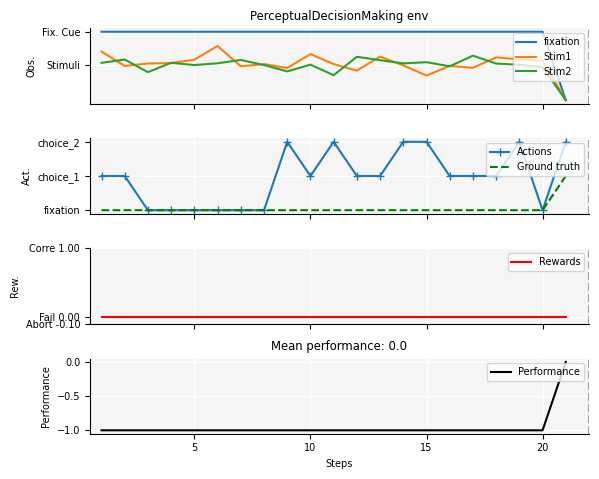

In [11]:
env = PerceptualDecisionMaking()
print("Coherences:", env.cohs)
print("Noise sigma:", env.sigma)
print("Timing:", env.timing)
print("Rewards:", env.rewards)

trial = env._new_trial()
env.reset()
print("trial used by env.reset():", env.trial)
obs_log = []
reward_log = []
info_log = []
done = False
while not done:
    obs, reward, terminated, truncated, info = env.step(0)
    print(info["gt"])
    obs_log.append(obs.copy())
    reward_log.append(reward)
    info_log.append(info)
    done = info["new_trial"]
fig = ngym.utils.plot_env(
    env,
    ob_traces=["fixation", "Stim1", "Stim2"],
    num_trials=1,
)

In [ ]:
class GoNogo(TrialEnv):
    """Go/No-go task.

    A stimulus is shown during the stimulus period. The stimulus period is
    followed by a delay period, and then a decision period. If the stimulus is
    a Go stimulus, then the subject should choose the action Go during the
    decision period, otherwise, the subject should remain fixation.
    Here we have 4 periods: fixation, stimulus, delay, decision.
    The observation space is a list with 3 values, one for fixation
    one for no-go, and one for go. The action space has two elements
    and the action must be an integer in {0, 1}. If it's 0 it means
    fixate and if it's 1 it means go.
    During a new trial, the ground truth is generated by sampling
    from choices, which is either 0 or 1: 0 is fixate, 1 is GO.
    In the observation space, self.add_ob(1, "stimulus", where=trial["ground_truth"] + 1)
    so during the stimulus period, we put a 1 in the 'trial["ground_truth"] + 1' position.
    If it's a nogo trial (ground_truth = 0), where = 0 + 1 = 1, so it sets obs[1] = 1 (nogo channel ON).
    Negative reward for miss is only during GO trials where it fails to GO:
    self.r_tmax = self.rewards["miss"] * trial["ground_truth"]
    Initially, the fixate flag is made 1, but then it is overwritten by
    self.set_ob(0, "decision") during the decision period:
    during the decision period, set the entire observation vector to zeros.
    So there is no more stimulus, but the agent needs to take the action.
    During "stimulus", you show either the go or nogo cue (obs[2]=1 or obs[1]=1).
    During "delay", the stimulus cue is gone, but fixation remains 1
    (so the network can keep internal state).
    During "decision", everything is removed ([0,0,0]) so the network must
    rely on its internal memory of what it saw during stimulus,
    not a cue that's still present.
    During the step, we penalize the system if it does anything other than
    fixate during the fixation period. If we are during decision period
    and the action is not fixate so if it's 1, then we look at what the
    ground truth is: if the ground truth = 0, then we penalize the agent,
    if it's equal to 1 then we reward the agent.
    If the agent never presses GO during the decision period (keeps action=0),
    the trial ends when the decision period times out; in that case it receives
    a miss penalty only on Go trials (r_tmax = miss when ground_truth=1, otherwise 0).
    The penalty is self.r_tmax and is implicitly taken by neurogym.
    
    """

    # TODO: Find the original go-no-go paper
    metadata = {  # noqa: RUF012
        "paper_link": "https://elifesciences.org/articles/43191",
        "paper_name": "Active information maintenance in working memory by a sensory cortex",
        "tags": ["delayed response", "go-no-go", "supervised"],
    }

    def __init__(self, dt=100, rewards=None, timing=None) -> None:
        super().__init__(dt=dt)
        # Actions are (FIXATE, GO)
        self.actions = [0, 1]
        # trial conditions
        self.choices = [0, 1]

        # Rewards
        self.rewards = {"abort": -0.1, "correct": +1.0, "fail": -0.5, "miss": -0.5}
        if rewards:
            self.rewards.update(rewards)

        self.timing = {"fixation": 0, "stimulus": 500, "delay": 500, "decision": 500}
        if timing:
            self.timing.update(timing)

        self.abort = False
        # set action and observation spaces
        name = {"fixation": 0, "nogo": 1, "go": 2}
        self.observation_space = ngym.spaces.Box(
            -np.inf,
            np.inf,
            shape=(3,),
            dtype=np.float32,
            name=name,
        )
        self.action_space = ngym.spaces.Discrete(2, {"fixation": 0, "go": 1})  # The action must be an integer in {0, 1}

    def _new_trial(self, **kwargs):
        # Trial info
        trial = {"ground_truth": self.rng.choice(self.choices)}
        trial.update(kwargs)

        # Period info
        periods = ["fixation", "stimulus", "delay", "decision"]
        self.add_period(periods)
        # set observations
        self.add_ob(1, where="fixation")
        self.add_ob(1, "stimulus", where=trial["ground_truth"] + 1) # If it's a nogo trial (ground_truth = 0), where = 0 + 1 = 1, so it sets obs[1] = 1 (nogo channel ON)
        self.set_ob(0, "decision")
        # if trial is GO the reward is set to R_MISS and to 0 otherwise
        self.r_tmax = self.rewards["miss"] * trial["ground_truth"]
        self.performance = 1 - trial["ground_truth"]
        # set ground truth during decision period
        self.set_groundtruth(trial["ground_truth"], "decision")

        return trial

    def _step(self, action):
        new_trial = False
        terminated = False
        truncated = False
        reward = 0
        ob = self.ob_now
        gt = self.gt_now
        if self.in_period("fixation"):
            if action != 0:
                new_trial = self.abort
                reward = self.rewards["abort"]
        elif self.in_period("decision") and action != 0:
            new_trial = True
            if gt != 0:
                reward = self.rewards["correct"]
                self.performance = 1
            else:
                reward = self.rewards["fail"]
                self.performance = 0

        return ob, reward, terminated, truncated, {"new_trial": new_trial, "gt": gt}

In [14]:
env = GoNogo()
env.reset()
# force a GO trial# safer: keep resetting until you get a GO trial
while True:
    env.reset()
    if env.trial["ground_truth"] == 1:
        break

print("trial:", env.trial, "r_tmax:", env.r_tmax)

while True:
    obs, reward, terminated, truncated, info = env.step(0)  # never GO
    print("reward:", reward, "new_trial:", info["new_trial"])
    if info["new_trial"]:
        break


trial: {'ground_truth': np.int64(1)} r_tmax: -0.5
reward: 0 new_trial: False
reward: 0 new_trial: False
reward: 0 new_trial: False
reward: 0 new_trial: False
reward: 0 new_trial: False
reward: 0 new_trial: False
reward: 0 new_trial: False
reward: 0 new_trial: False
reward: 0 new_trial: False
reward: 0 new_trial: False
reward: 0 new_trial: False
reward: 0 new_trial: False
reward: 0 new_trial: False
reward: -0.5 new_trial: True


In [137]:
env = GoNogo()
env.reset(options={"no_step": True})
print("trial used by env.reset():", env.trial)
obs_log = []
reward_log = []
info_log = []
done = False
while not done:
    obs, reward, terminated, truncated, info = env.step(0)
    print(info["gt"])
    obs_log.append(obs.copy())
    reward_log.append(reward)
    info_log.append(info)
    done = info["new_trial"]

trial used by env.reset(): {'ground_truth': np.int64(0)}
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [138]:
obs_log

[array([1., 1., 0.], dtype=float32),
 array([1., 1., 0.], dtype=float32),
 array([1., 1., 0.], dtype=float32),
 array([1., 1., 0.], dtype=float32),
 array([1., 0., 0.], dtype=float32),
 array([1., 0., 0.], dtype=float32),
 array([1., 0., 0.], dtype=float32),
 array([1., 0., 0.], dtype=float32),
 array([1., 0., 0.], dtype=float32),
 array([0., 0., 0.], dtype=float32),
 array([0., 0., 0.], dtype=float32),
 array([0., 0., 0.], dtype=float32),
 array([0., 0., 0.], dtype=float32),
 array([0., 0., 0.], dtype=float32),
 array([1., 1., 0.], dtype=float32)]